In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [28]:
df = pd.read_csv("data/celsius_a_fahrenheit.csv")
df.head()

celcius = np.array(df['Celsius'], dtype=float)
farenheit = np.array(df['Fahrenheit'], dtype=float)

print(f"Celsius: {celcius[:5]}")
print(f"Fahrenheit: {farenheit[:5]}")



Celsius: [-50. -40. -30. -20. -10.]
Fahrenheit: [-58. -40. -22.  -4.  14.]


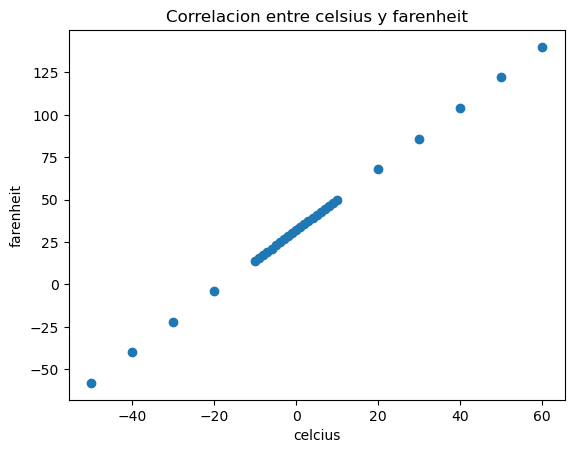

In [29]:
plt.scatter(celcius,farenheit)
plt.title('Correlacion entre celsius y farenheit')
plt.xlabel('celcius')
plt.ylabel('farenheit')

plt.show()


<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

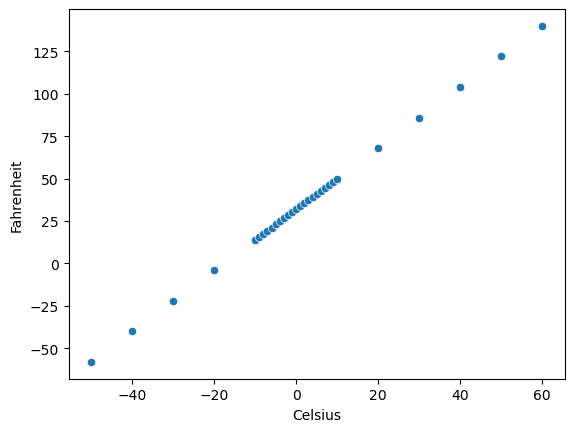

In [30]:
sb.scatterplot(x='Celsius', y='Fahrenheit', data=df)

In [31]:
X_train = celcius
Y_train = farenheit

In [32]:
print("Creando el modelo")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(units=1))

Creando el modelo


In [33]:
print('Compilando el modelo')
model.compile(
    optimizer=tf.keras.optimizers.Adam(1.0),
    loss='mean_squared_error'
)

Compilando el modelo


In [34]:
print('entrenadno el modelo')
epochs_hist = model.fit(X_train, Y_train, epochs=1000)

entrenadno el modelo
Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - loss: 1044.7712
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1249.3279
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 926.8422
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 883.2540
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 928.3776
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 817.5765
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 681.8058
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 637.4027
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 644.8764
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 606.3954
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 519.4484
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 445.8360
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 419.2551
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 411.1518
Epoch 15/1000
1/1 ━

In [35]:
print('evaluando el modelo entrenado')
print('keys:')
print(epochs_hist.history.keys())

evaluando el modelo entrenado
keys:
dict_keys(['loss'])


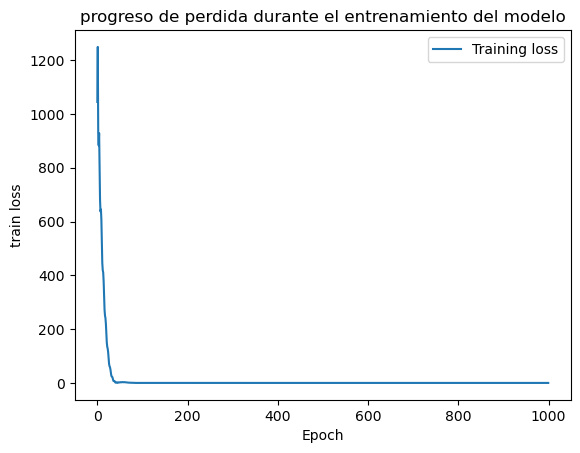

In [36]:
plt.plot(epochs_hist.history['loss'])
plt.title('progreso de perdida durante el entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('train loss')
plt.legend(['Training loss'])
plt.show()

In [37]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)
print('temperatura de prediccion: '+str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
temperatura de prediccion: [[212.]]


In [38]:
Temp_F = 9/5 * Temp_C + 32
print('temperatura de ecuacion: '+ str(Temp_F))

temperatura de ecuacion: 212.0


In [39]:
oculta1 = tf.keras.layers.Dense(units=32, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1,oculta2,salida])

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

[array([[ 0.04106191,  0.15580201,  0.33768028,  0.36008656,  0.36782408,
         0.25274926, -0.02649364,  0.37552083, -0.07622996,  0.10411513,
         0.31642509,  0.39178145, -0.4230165 ,  0.21739358,  0.06969634,
         0.1373213 ,  0.00750783,  0.07094678,  0.36831886,  0.01066548,
        -0.19839455, -0.04075772,  0.32512838,  0.1816979 ,  0.19016886,
         0.27960443, -0.40039   , -0.3246898 , -0.2906974 , -0.37892303,
         0.29265416,  0.28936774]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)]
[array([[ 0.05799705,  0.19325903,  0.19206205],
       [ 0.37590674, -0.13257104,  0.3327481 ],
       [ 0.1199024 ,  0.23494479,  0.39074937],
       [ 0.12893447, -0.37224898,  0.17181829],
       [ 0.17959103, -0.16775393,  0.09356126],
       [ 0.32347468, -0.3617419 ,  0.07419199],
       [-0.03576019, -0.22583024,  0.28656206],
       

c:\Users\herna\anaconda3\envs\notebooks\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**El optimizador de algoritmo utilizado es Adam, pero existen otros como SGD y RMSProp, describe cada uno de ello y explica como pudieran cambiar los resultados de tu modelo.**

adam es la que combina las entajas de adagard y rmsprop. adapta las tasas de aprendizaje para cada parametro, mantiene las tasas de aprendisajes adaptativas, usa momentum ara acelerar las convergencias y es el mas popular y eficiente.

im imporntante es que converge rapido y de forma estable

Describe porque es importante agregar una función de pérdida como 'mean_squared_error ', investiga que otra función de pérdida se puede implementar y como alteraría los resultados.


En las modificaciones realizadas,  cuantas epocas fueron 'suficientes' para que el modelo se considere entrenado para ponerlo en funcionamiento.


¿Por qué son importantes las epoch?


Que función de activación utiliza el modelo? ¿Es posible cambiarla? Si es así, cambia a una función RELU y muestra el resultado.